<a href="https://colab.research.google.com/github/kundankumar09-v/weekly_assignments_CEI/blob/main/week4_kundan_kumar_vennaboiona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3496s 21us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

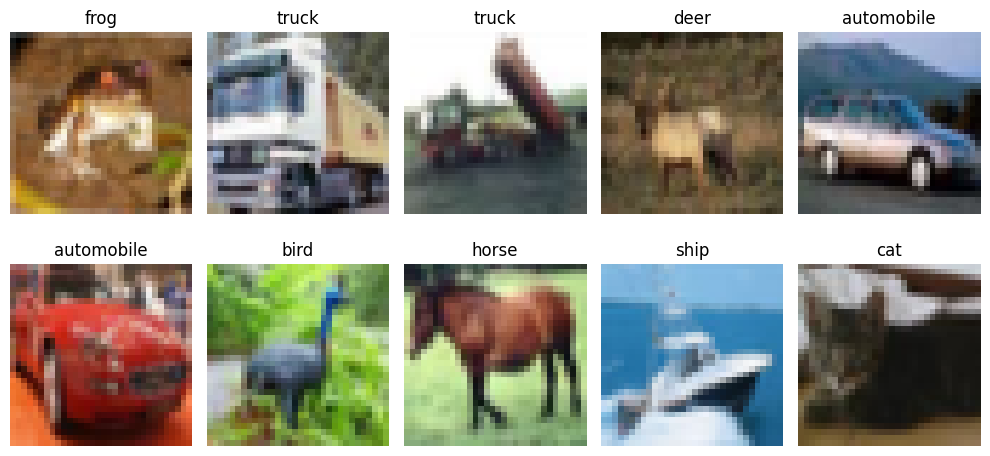

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.2717 - loss: 1.9938 - val_accuracy: 0.3318 - val_loss: 1.8388
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3246 - loss: 1.8523 - val_accuracy: 0.3408 - val_loss: 1.8164
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3388 - loss: 1.8091 - val_accuracy: 0.3680 - val_loss: 1.7336
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3526 - loss: 1.7727 - val_accuracy: 0.3870 - val_loss: 1.7133
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3658 - loss: 1.7455 - val_accuracy: 0.4028 - val_loss: 1.6851
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3758 - loss: 1.7119 - val_accuracy: 0.4192 - val_loss: 1.6495
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3816 - loss: 1.7066 - val_accuracy: 0.4184 - val_loss: 1.6521
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3912 - loss: 1.6849 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 129ms/step - accuracy: 0.4784 - loss: 1.4669 - val_accuracy: 0.5052 - val_loss: 1.3853
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6117 - loss: 1.1078 - val_accuracy: 0.5694 - val_loss: 1.2130
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 128ms/step - accuracy: 0.6742 - loss: 0.9389 - val_accuracy: 0.5804 - val_loss: 1.2022
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.7165 - loss: 0.8209 - val_accuracy: 0.6502 - val_loss: 0.9765
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7487 - loss: 0.7219 - val_accuracy: 0.7148 - val_loss: 0.8097
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 137ms/step - accuracy: 0.7732 - loss: 0.6516 - val_accuracy: 0.7140 - val_loss: 0.8276
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 134ms/step - accuracy: 0.7959 - loss: 0.5849 - val_accuracy: 0.6780 - val_loss: 0.9603
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 134ms/step - accuracy: 0.8148 - loss

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7011 - loss: 0.9828
CNN Test Accuracy: 0.7010999917984009


## 📈 Compare Learning Curves

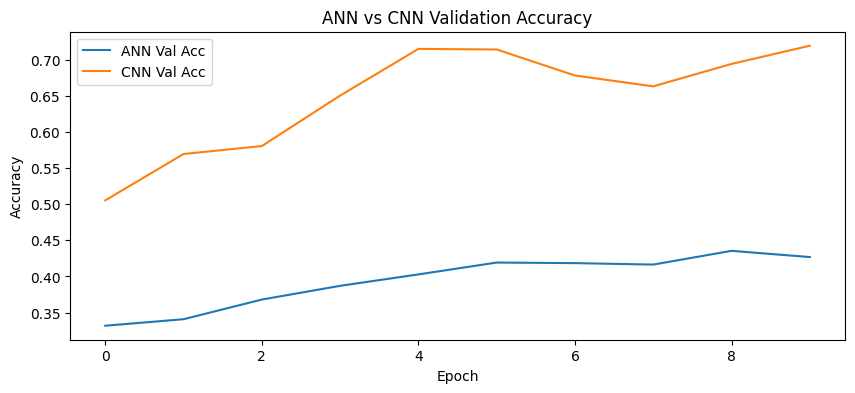

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4282
1,CNN,0.7011


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

### ✅ Beginner Tasks - Solutions

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#### Task 1: Increase ANN layers and observe performance

In [ ]:

ann_model_task1 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_task1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ANN Model with more layers...")
ann_history_task1 = ann_model_task1.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training ANN Model with more layers...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.2471 - loss: 2.0321 - val_accuracy: 0.3404 - val_loss: 1.8657
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3010 - loss: 1.8964 - val_accuracy: 0.3402 - val_loss: 1.8364
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3206 - loss: 1.8451 - val_accuracy: 0.3448 - val_loss: 1.7968
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3330 - loss: 1.8210 - val_accuracy: 0.3544 - val_loss: 1.7931
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.3449 - loss: 1.7928 - val_accuracy: 0.3860 - val_loss: 1.7389
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3509 - loss: 1.7766 - val_accuracy: 0.3948 - val_loss: 1.7093
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.3620 - loss: 1.7625 - val_accuracy: 0.3878 - val_loss: 1.7280
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/st

In [ ]:
ann_test_loss_task1, ann_test_acc_task1 = ann_model_task1.evaluate(x_test_flat, y_test)
print(f"ANN (More Layers) Test Accuracy: {ann_test_acc_task1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4142 - loss: 1.6932
ANN (More Layers) Test Accuracy: 0.4142


#### Task 3 & 4: ANN with 20 Epochs and EarlyStopping

In [ ]:

ann_model_es = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ANN Model with 20 Epochs and EarlyStopping...")
ann_history_es = ann_model_es.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping_cb]
)

Training ANN Model with 20 Epochs and EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2675 - loss: 2.0046 - val_accuracy: 0.3112 - val_loss: 1.8935
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.3055 - loss: 1.8867 - val_accuracy: 0.3474 - val_loss: 1.8153
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.3317 - loss: 1.8330 - val_accuracy: 0.3702 - val_loss: 1.7653
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3430 - loss: 1.7980 - val_accuracy: 0.3726 - val_loss: 1.7418
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3562 - loss: 1.7654 - val_accuracy: 0.3924 - val_loss: 1.7055
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3646 - loss: 1.7399 - val_accuracy: 0.3990 - val_loss: 1.6950
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.3697 - loss: 1.7311 - val_accuracy: 0.4088 - val_loss: 1.6735
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━

In [ ]:
ann_test_loss_es, ann_test_acc_es = ann_model_es.evaluate(x_test_flat, y_test)
print(f"ANN (ES, 20 Epochs) Test Accuracy: {ann_test_acc_es:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4520 - loss: 1.5505
ANN (ES, 20 Epochs) Test Accuracy: 0.4520


#### Task 2, 3 & 4: CNN with 20 Epochs and EarlyStopping (filters 32-64-128 are already set in original CNN model)

In [ ]:

cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model with 20 Epochs and EarlyStopping...")
cnn_history_es = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping_cb]
)

Training CNN Model with 20 Epochs and EarlyStopping...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 131ms/step - accuracy: 0.4822 - loss: 1.4550 - val_accuracy: 0.5828 - val_loss: 1.1778
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 136ms/step - accuracy: 0.6162 - loss: 1.0896 - val_accuracy: 0.5774 - val_loss: 1.2579
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 136ms/step - accuracy: 0.6770 - loss: 0.9338 - val_accuracy: 0.6880 - val_loss: 0.8922
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.7144 - loss: 0.8190 - val_accuracy: 0.6480 - val_loss: 1.0145
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 131ms/step - accuracy: 0.7430 - loss: 0.7321 - val_accuracy: 0.6904 - val_loss: 0.9169
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7727 - loss: 0.6516 - val_accuracy: 0.6616 - val_loss: 1.0342
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7862 - loss: 0.6054 - val_accuracy: 0.6828 - val_loss: 0.9718
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 131ms/step - accuracy: 0.8116 - los

In [ ]:
cnn_test_loss_es, cnn_test_acc_es = cnn_model_es.evaluate(x_test_norm, y_test)
print(f"CNN (ES, 20 Epochs) Test Accuracy: {cnn_test_acc_es:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6712 - loss: 0.9423
CNN (ES, 20 Epochs) Test Accuracy: 0.6712


#### Task 5: Add data augmentation training

In [ ]:

aug_cnn_model_trained = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model_trained.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Augmented CNN Model with 20 Epochs and EarlyStopping...")
aug_history = aug_cnn_model_trained.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping_cb]
)

Training Augmented CNN Model with 20 Epochs and EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 108s 147ms/step - accuracy: 0.4115 - loss: 1.6282 - val_accuracy: 0.4816 - val_loss: 1.4300
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 107s 152ms/step - accuracy: 0.5080 - loss: 1.3815 - val_accuracy: 0.5202 - val_loss: 1.3934
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 110s 157ms/step - accuracy: 0.5541 - loss: 1.2615 - val_accuracy: 0.5854 - val_loss: 1.1545
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 156ms/step - accuracy: 0.5804 - loss: 1.1979 - val_accuracy: 0.5608 - val_loss: 1.3292
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 149ms/step - accuracy: 0.5987 - loss: 1.1447 - val_accuracy: 0.6068 - val_loss: 1.1292


In [ ]:
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model_trained.evaluate(x_test_norm, y_test)
print(f"Augmented CNN (ES, 20 Epochs) Test Accuracy: {aug_cnn_test_acc:.4f}")

#### Updated Final Comparison Table

In [ ]:
updated_comparison = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "ANN (More Layers)",
        "ANN (ES, 20 Epochs)",
        "CNN (Original)",
        "CNN (ES, 20 Epochs)",
        "Augmented CNN (ES, 20 Epochs)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        ann_test_acc_task1,
        ann_test_acc_es,
        cnn_test_acc,
        cnn_test_acc_es,
        aug_cnn_test_acc
    ]
})

display(updated_comparison.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True))

,Model,Test Accuracy
0,CNN (Original),0.7011
1,"CNN (ES, 20 Epochs)",0.6712
2,"Augmented CNN (ES, 20 Epochs)",0.4870
3,"ANN (ES, 20 Epochs)",0.4520
4,ANN (Original),0.4282
5,ANN (More Layers),0.4142
